# 6. Transformer Encoder / Decoder 层组装 —— 手搓 NumPy vs PyTorch

把前面学的零件（多头注意力、FFN、LayerNorm）组装成真正的 Transformer 层：
**Encoder 层**（两子层）与 **Decoder 层**（三子层，含交叉注意力），并对比 torch 组装。
最后讨论一个关键问题：现代 LLM（MiniMind/LLaMA）为什么放弃 Encoder-Decoder、改用 Decoder-only？


## 公式回顾

**Encoder 层（Post-LN）**——两子层：

$$x \leftarrow \mathrm{LN}\big(x + \mathrm{MHA}(x,x,x)\big) \qquad (\text{自注意力}+\text{残差}+\text{LN})$$
$$x \leftarrow \mathrm{LN}\big(x + \mathrm{FFN}(x)\big)$$

**Decoder 层（Post-LN）**——三子层：

1. 掩码自注意力：$\hat{x} = LN(x + MaskedMHA(x,x,x))$
2. 交叉注意力：$x' = LN(\hat{x} + MHA(\hat{x}, enc\_out, enc\_out))$ —— **Q 来自 decoder，K/V 来自 encoder 输出**
3. FFN：$x'' = LN(x' + FFN(x'))$

注意交叉注意力里 K/V 的投影权重属于"encoder 侧的参数组"，而 Q 的投影属于 decoder 侧。


## 导入 + 简版子模块

超参：$d_{model}=8,\ h=2,\ d_k=d_v=4,\ d_{ff}=16,\ B=2,\ T=4$；种子 0。


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

np.random.seed(0)
torch.manual_seed(0)

def softmax_rows(x):
    """数值稳定 softmax（沿最后一维，每行独立）。"""
    x = x - np.max(x, axis=-1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=-1, keepdims=True)

def np_attention(Q, K, V, mask=None):
    """简版缩放点积注意力：Q,K,V [B,T,d_k]；mask 为 True 处填 -inf。"""
    dk = Q.shape[-1]
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    attn = softmax_rows(scores)
    return np.matmul(attn, V)

def np_layernorm(x, gamma, beta, eps=1e-5):
    """LayerNorm：gamma/beta 可学习，沿最后一维归一化。"""
    mu = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    xhat = (x - mu) / np.sqrt(var + eps)
    return gamma * xhat + beta

def np_linear(x, W, b):
    """线性层：y = x@W + b（W: [in,out] 手搓约定）。"""
    return x @ W + b

def np_gelu(x):
    """GELU（tanh 近似，与 torch F.gelu(approximate='tanh') 逐位一致）：
    g = 0.5x(1+tanh(√(2/π)(x+0.044715x³)))"""
    a = math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)
    return 0.5 * x * (1.0 + np.tanh(a))

def np_mha(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k, mask=None):
    """简版多头注意力（复用第 2 讲五步法，返回拼接投影后的 [B,T,d_model]）。"""
    B, T, d_model = x.shape
    Q = x @ Wq + bq
    K = x @ Wk + bk
    V = x @ Wv + bv
    Q = Q.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)
    K = K.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)
    V = V.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)
    heads = [np_attention(Q[:, i], K[:, i], V[:, i], mask) for i in range(h)]
    concat = np.concatenate(heads, axis=-1)
    return concat @ Wo + bo


## 手搓 Encoder 层（Post-LN）

- 子层 1：自注意力（Q=K=V=x）+ 残差 + LayerNorm
- 子层 2：FFN（用手搓两层线性+ReLU）+ 残差 + LayerNorm


In [5]:
def np_encoder_layer(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, W1, b1, W2, b2, gamma1, beta1, gamma2, beta2, h, d_k):
    """手搓 Encoder 单层（Post-LN）：
    x1 = LN(x + MHA(x,x,x))；x2 = LN(x1 + FFN(x1))。返回 x2 [B,T,d_model]。"""
    # 子层 1：自注意力 + 残差 + LN
    attn_out = np_mha(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k)   # 自注意力（Q=K=V=x）
    x1 = np_layernorm(x + attn_out, gamma1, beta1)                  # 残差 + LayerNorm
    # 子层 2：FFN + 残差 + LN
    h1 = np_linear(x1, W1, b1)                                      # FFN：升维
    h2 = np_gelu(h1)                                                # GELU（tanh 近似，与 torch 对齐）
    ffn_out = np_linear(h2, W2, b2)                                 # FFN：降维
    x2 = np_layernorm(x1 + ffn_out, gamma2, beta2)                  # 残差 + LayerNorm
    return x2


## 手搓 Decoder 层（Post-LN，三子层）

Decoder 比 Encoder 多了**交叉注意力**：Q 来自 decoder 自身中间表示，
而 K/V 来自 **encoder 的输出**（所以交叉注意力需要 encoder 侧的 Wk/Wv 参数组）。
另外自注意力要加**因果掩码**（上三角 -inf，解码时不能看未来）。


In [7]:
def np_decoder_layer(x, enc_out, Wq, Wk, Wv, Wo, bq, bk, bv, bo,
                      Wk_enc, Wv_enc, bk_enc, bv_enc,   # encoder 侧的 K/V 投影参数
                      W1, b1, W2, b2, gamma1, beta1, gamma2, beta2, gamma3, beta3, h, d_k, T):
    """手搓 Decoder 单层（Post-LN）：
    ①掩码自注意力；②交叉注意力（K/V 来自 enc_out）；③FFN。返回 x [B,T,d_model]。"""
    causal = np.triu(np.ones((T, T)), 1).astype(bool)   # 上三角 = 未来位置，掩码
    # ① 掩码自注意力 + 残差 + LN
    sa = np_mha(x, Wq, Wk, Wv, Wo, bq, bk, bv, bo, h, d_k, mask=causal)
    x1 = np_layernorm(x + sa, gamma1, beta1)
    # ② 交叉注意力：Q 投影用 decoder 的 Wq，K/V 投影用 encoder 的 Wk_enc/Wv_enc
    B, T_, d_model = x.shape
    # 手动实现交叉注意力（Q 来自 x1，K/V 来自 enc_out）
    Q = x1 @ Wq + bq
    K = enc_out @ Wk_enc + bk_enc          # K 来自 encoder 输出！
    V = enc_out @ Wv_enc + bv_enc          # V 来自 encoder 输出！
    Q = Q.reshape(B, T_, h, d_k).transpose(0, 2, 1, 3)
    K = K.reshape(B, T_, h, d_k).transpose(0, 2, 1, 3)
    V = V.reshape(B, T_, h, d_k).transpose(0, 2, 1, 3)
    heads = [np_attention(Q[:, i], K[:, i], V[:, i]) for i in range(h)]
    cross = np.concatenate(heads, axis=-1) @ Wo + bo
    x2 = np_layernorm(x1 + cross, gamma2, beta2)
    # ③ FFN + 残差 + LN
    h1 = np_gelu(np_linear(x2, W1, b1))          # FFN：升维 + GELU
    ffn_out = np_linear(h1, W2, b2)              # FFN：降维
    x3 = np_layernorm(x2 + ffn_out, gamma3, beta3)
    return x3


## PyTorch 组装参考

用 `nn.MultiheadAttention + nn.LayerNorm + nn.Linear + nn.GELU` 组装 Encoder/Decoder 层。
**对齐细节**：in_proj_weight 行序 [Wq;Wk;Wv]、每分块转置、batch_first=True、
attn_mask（torch 用 `torch.triu(ones,1).bool()` 布尔掩码，内部填 -inf）。


In [9]:
def torch_mha(d_model, h, Wq, Wk, Wv, Wo, bq, bk, bv, bo):
    """构造 torch 多头注意力并载入与手搓相同的权重（注意转置约定）。"""
    m = nn.MultiheadAttention(d_model, h, batch_first=True, dtype=torch.float64)
    m.in_proj_weight.data = torch.cat([torch.tensor(Wq.T), torch.tensor(Wk.T), torch.tensor(Wv.T)], dim=0)
    m.in_proj_bias.data = torch.cat([torch.tensor(bq), torch.tensor(bk), torch.tensor(bv)], dim=0)
    m.out_proj.weight.data = torch.tensor(Wo.T)
    m.out_proj.bias.data = torch.tensor(bo)
    return m

def torch_encoder_layer(x, params, h, d_k, causal_mask=None):
    """torch 版 Encoder 层：自注意力 + FFN（GELU），Post-LN。"""
    mha = torch_mha(params['d_model'], h, params['Wq'], params['Wk'], params['Wv'], params['Wo'],
                    params['bq'], params['bk'], params['bv'], params['bo'])
    attn, _ = mha(x, x, x)
    x1 = params['ln1'](x + attn)
    h1 = params['lin1'](x1)
    ffn = params['lin2'](F.gelu(h1, approximate='tanh'))
    return params['ln2'](x1 + ffn)


## 数值对比验证


In [11]:
B, T, d_model, h, d_k, d_ff = 2, 4, 8, 2, 4, 16

# ---- 生成一套手搓权重（decoder 与 encoder 各自一套） ----
def rand_weights():
    w = {}
    for k in ['Wq', 'Wk', 'Wv', 'Wo']:
        w[k] = np.random.randn(d_model, d_model) * 0.05
    for k in ['bq', 'bk', 'bv', 'bo']:
        w[k] = np.random.randn(d_model) * 0.05
    w['W1'] = np.random.randn(d_model, d_ff) * 0.05
    w['b1'] = np.random.randn(d_ff) * 0.05
    w['W2'] = np.random.randn(d_ff, d_model) * 0.05
    w['b2'] = np.random.randn(d_model) * 0.05
    for i in range(1, 3):
        w[f'gamma{i}'] = np.random.randn(d_model) * 0.1 + 1
        w[f'beta{i}'] = np.random.randn(d_model) * 0.1
    w['d_model'] = d_model
    return w

enc_w = rand_weights()
dec_w = rand_weights()
# decoder 的交叉注意力 K/V 投影用 encoder 的参数组
enc_kv = {'Wk': enc_w['Wk'], 'Wv': enc_w['Wv'], 'bk': enc_w['bk'], 'bv': enc_w['bv']}

x_np = np.random.randn(B, T, d_model)
enc_kv = {'Wk': enc_w['Wk'], 'Wv': enc_w['Wv'], 'bk': enc_w['bk'], 'bv': enc_w['bv']}

def np_encoder(x, w, h, d_k):
    return np_encoder_layer(x, w['Wq'], w['Wk'], w['Wv'], w['Wo'], w['bq'], w['bk'], w['bv'], w['bo'],
                            w['W1'], w['b1'], w['W2'], w['b2'], w['gamma1'], w['beta1'], w['gamma2'], w['beta2'], h, d_k)

def np_decoder(x, enc_out, w, enc_kv, h, d_k, T):
    return np_decoder_layer(x, enc_out, w['Wq'], w['Wk'], w['Wv'], w['Wo'], w['bq'], w['bk'], w['bv'], w['bo'],
                            enc_kv['Wk'], enc_kv['Wv'], enc_kv['bk'], enc_kv['bv'],
                            w['W1'], w['b1'], w['W2'], w['b2'],
                            w['gamma1'], w['beta1'], w['gamma2'], w['beta2'],
                            w.get('gamma3', w['gamma1']), w.get('beta3', w['beta1']), h, d_k, T)

# ---- 手搓 ----
enc_out = np_encoder(x_np, enc_w, h, d_k)
dec_out = np_decoder(x_np, enc_out, dec_w, enc_kv, h, d_k, T)

# ---- torch 组装 ----
from torch import nn as nn2

def torch_ln(gamma, beta, d_model):
    """构造 torch LayerNorm 并载入手搓的 gamma/beta（默认是 weight=1/bias=0，必须载入）。"""
    l = nn2.LayerNorm(d_model, dtype=torch.float64)
    l.weight.data = torch.tensor(gamma)
    l.bias.data = torch.tensor(beta)
    return l

ln_e1 = torch_ln(enc_w['gamma1'], enc_w['beta1'], d_model)   # encoder 的两个 LN
ln_e2 = torch_ln(enc_w['gamma2'], enc_w['beta2'], d_model)
ln_d1 = torch_ln(dec_w['gamma1'], dec_w['beta1'], d_model)   # decoder 的三个 LN
ln_d2 = torch_ln(dec_w['gamma2'], dec_w['beta2'], d_model)
ln_d3 = torch_ln(dec_w.get('gamma3', dec_w['gamma1']), dec_w.get('beta3', dec_w['beta1']), d_model)

def torch_enc(x_t, w, h):
    mha = torch_mha(d_model, h, w['Wq'], w['Wk'], w['Wv'], w['Wo'], w['bq'], w['bk'], w['bv'], w['bo'])
    a, _ = mha(x_t, x_t, x_t)
    x1 = ln_e1(x_t + a)
    hh = F.gelu(w['lin1_t'](x1), approximate='tanh')
    return ln_e2(x1 + w['lin2_t'](hh))

# 构造 torch 线性层并载权重
def torch_lin(in_f, out_f, W, b):
    l = nn2.Linear(in_f, out_f, dtype=torch.float64)
    l.weight.data = torch.tensor(W.T); l.bias.data = torch.tensor(b)
    return l

enc_w['lin1_t'] = torch_lin(d_model, d_ff, enc_w['W1'], enc_w['b1'])
enc_w['lin2_t'] = torch_lin(d_ff, d_model, enc_w['W2'], enc_w['b2'])
dec_w['lin1_t'] = torch_lin(d_model, d_ff, dec_w['W1'], dec_w['b1'])
dec_w['lin2_t'] = torch_lin(d_ff, d_model, dec_w['W2'], dec_w['b2'])

x_t = torch.tensor(x_np, dtype=torch.float64)
enc_out_t = torch_enc(x_t, enc_w, h)
e1 = float((enc_out_t.detach().numpy() - enc_out).max())
assert np.allclose(enc_out, enc_out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'1) Encoder 层输出 :  max abs err = {e1:.3e}   ->  PASS')

# torch decoder：掩码自注意力 + 交叉注意力（Q 来自 decoder，K/V 来自 encoder 输出）
causal = torch.triu(torch.ones(T, T), 1).bool()
dec_mha_sa = torch_mha(d_model, h, dec_w['Wq'], dec_w['Wk'], dec_w['Wv'], dec_w['Wo'],
                       dec_w['bq'], dec_w['bk'], dec_w['bv'], dec_w['bo'])
dec_mha_cross = torch_mha(d_model, h, dec_w['Wq'], enc_kv['Wk'], enc_kv['Wv'], dec_w['Wo'],
                          dec_w['bq'], enc_kv['bk'], enc_kv['bv'], dec_w['bo'])
x1_t = x_t
a1, _ = dec_mha_sa(x1_t, x1_t, x1_t, attn_mask=causal)
x1_t = ln_d1(x1_t + a1)
a2, _ = dec_mha_cross(x1_t, enc_out_t, enc_out_t)
x2_t = ln_d2(x1_t + a2)
hh = F.gelu(dec_w['lin1_t'](x2_t), approximate='tanh')
dec_out_t = ln_d3(x2_t + dec_w['lin2_t'](hh))
e2 = float((dec_out_t.detach().numpy() - dec_out).max())
assert np.allclose(dec_out, dec_out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'2) Decoder 层输出 :  max abs err = {e2:.3e}   ->  PASS')
print()
print('== 全部对比通过 ==')


1) Encoder 层输出 :  max abs err = 4.441e-16   ->  PASS
2) Decoder 层输出 :  max abs err = 4.441e-16   ->  PASS

== 全部对比通过 ==


## 中间过程可视化：层结构图

用框图展示 Encoder/Decoder 单层的子层顺序与张量形状（讲课投屏利器）。


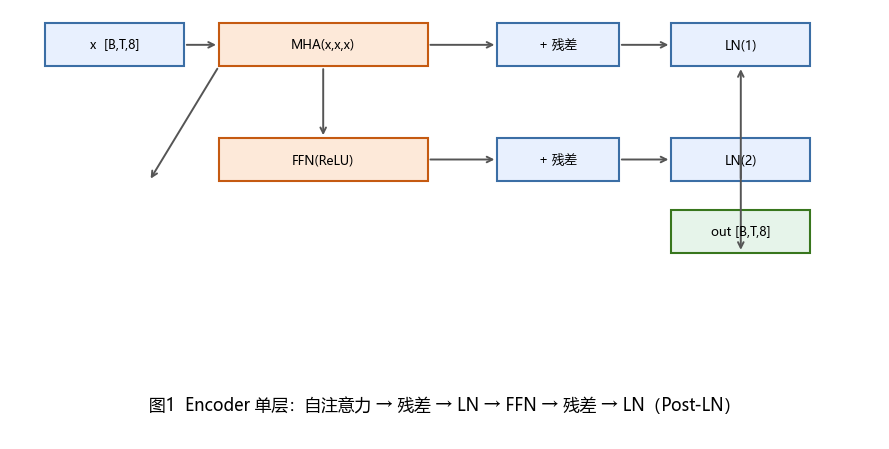

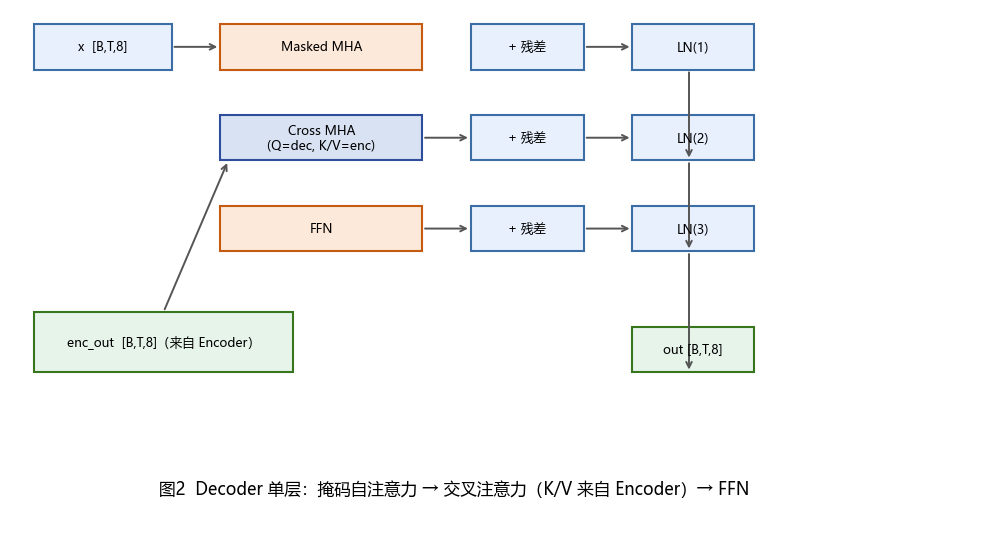

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def box(ax, x, y, w, h, text, fc='#E8F0FE', ec='#3B6EA5'):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=9)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.4))

# ---- 图1：Encoder 单层结构 ----
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
box(ax, 0.4, 5.2, 1.6, 0.6, 'x  [B,T,8]')
box(ax, 2.4, 5.2, 2.4, 0.6, 'MHA(x,x,x)', fc='#FDE9D9', ec='#C55A11')
arrow(ax, 2.0, 5.5, 2.4, 5.5)
arrow(ax, 2.4, 5.2, 1.6, 3.6)          # 残差旁路
arrow(ax, 4.8, 5.5, 5.6, 5.5)
box(ax, 5.6, 5.2, 1.4, 0.6, '+ 残差')
arrow(ax, 7.0, 5.5, 7.6, 5.5)
box(ax, 7.6, 5.2, 1.6, 0.6, 'LN(1)')
arrow(ax, 8.4, 3.6, 8.4, 5.2)
box(ax, 2.4, 3.6, 2.4, 0.6, 'FFN(ReLU)', fc='#FDE9D9', ec='#C55A11')
arrow(ax, 3.6, 5.2, 3.6, 4.2)
arrow(ax, 4.8, 3.9, 5.6, 3.9)
box(ax, 5.6, 3.6, 1.4, 0.6, '+ 残差')
arrow(ax, 7.0, 3.9, 7.6, 3.9)
box(ax, 7.6, 3.6, 1.6, 0.6, 'LN(2)')
arrow(ax, 8.4, 3.9, 8.4, 2.6)
box(ax, 7.6, 2.6, 1.6, 0.6, 'out [B,T,8]', fc='#E6F4EA', ec='#38761D')
ax.text(5, 0.4, '图1  Encoder 单层：自注意力 → 残差 → LN → FFN → 残差 → LN（Post-LN）',
        ha='center', fontsize=12)
plt.tight_layout(); plt.show()

# ---- 图2：Decoder 单层结构 ----
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.set_xlim(0, 12); ax.set_ylim(0, 7); ax.axis('off')
box(ax, 0.3, 6.2, 1.7, 0.6, 'x  [B,T,8]')
box(ax, 2.6, 6.2, 2.5, 0.6, 'Masked MHA', fc='#FDE9D9', ec='#C55A11')
arrow(ax, 2.0, 6.5, 2.6, 6.5)
box(ax, 5.7, 6.2, 1.4, 0.6, '+ 残差')
arrow(ax, 7.1, 6.5, 7.7, 6.5)
box(ax, 7.7, 6.2, 1.5, 0.6, 'LN(1)')
arrow(ax, 8.4, 6.2, 8.4, 5.0)
box(ax, 2.6, 5.0, 2.5, 0.6, 'Cross MHA\n(Q=dec, K/V=enc)', fc='#D9E2F3', ec='#2E4E9C')
box(ax, 0.3, 2.2, 3.2, 0.8, 'enc_out  [B,T,8]（来自 Encoder）', fc='#E6F4EA', ec='#38761D')
arrow(ax, 1.9, 3.0, 2.7, 5.0)   # K/V 来源
arrow(ax, 5.1, 5.3, 5.7, 5.3)
box(ax, 5.7, 5.0, 1.4, 0.6, '+ 残差')
arrow(ax, 7.1, 5.3, 7.7, 5.3)
box(ax, 7.7, 5.0, 1.5, 0.6, 'LN(2)')
arrow(ax, 8.4, 5.0, 8.4, 3.8)
box(ax, 2.6, 3.8, 2.5, 0.6, 'FFN', fc='#FDE9D9', ec='#C55A11')
arrow(ax, 5.1, 4.1, 5.7, 4.1)
box(ax, 5.7, 3.8, 1.4, 0.6, '+ 残差')
arrow(ax, 7.1, 4.1, 7.7, 4.1)
box(ax, 7.7, 3.8, 1.5, 0.6, 'LN(3)')
arrow(ax, 8.4, 3.8, 8.4, 2.2)
box(ax, 7.7, 2.2, 1.5, 0.6, 'out [B,T,8]', fc='#E6F4EA', ec='#38761D')
ax.text(5.5, 0.6, '图2  Decoder 单层：掩码自注意力 → 交叉注意力（K/V 来自 Encoder）→ FFN', ha='center', fontsize=12)
plt.tight_layout(); plt.show()


## Decoder-only：现代 LLM 的选择

| | 原始 Transformer | 现代 LLM（GPT / LLaMA / MiniMind） |
|---|---|---|
| 结构 | Encoder-Decoder | **Decoder-only** |
| 任务 | 翻译等 seq2seq | 自回归生成（next token） |
| 归一化 | Post-LN | Pre-LN（梯度更稳） |
| 位置编码 | 正弦 | RoPE |
| 激活 | ReLU | GELU / SiLU（SwiGLU） |

**为什么 Decoder-only 成为主流**：
1. 自回归生成天然统一（输入输出同流，无需单独的编码器）
2. 更简单：一套参数、一种训练目标（next-token prediction）即可做预训练 + 微调 + RLHF
3. 实验表明同规模下 Decoder-only 效果不输 Encoder-Decoder（Google T5 研究、GPT 系列验证）
4. 推理用 KV cache 高效增量解码（第 9 讲细讲）

MiniMind 就是纯 Decoder-only（LLaMA 风格）：`embed → N×(RMSNorm→GQA Attn(RoPE)→残差→RMSNorm→SwiGLU)→final RMSNorm→lm_head`。


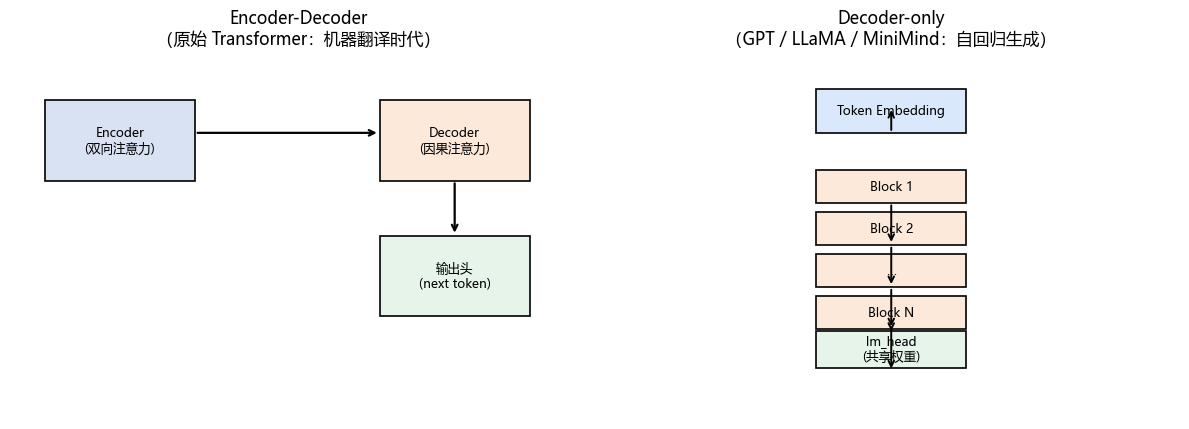

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
# 左：Encoder-Decoder
ax = axes[0]; ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
box = lambda ax, x, y, w, h, t, fc: (ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec='k', lw=1.2)), ax.text(x + w/2, y + h/2, t, ha='center', va='center', fontsize=9))
box(ax, 0.6, 6.5, 2.6, 2.2, 'Encoder\n(双向注意力)', '#D9E2F3')
box(ax, 6.4, 6.5, 2.6, 2.2, 'Decoder\n(因果注意力)', '#FDE9D9')
box(ax, 6.4, 2.8, 2.6, 2.2, '输出头\n(next token)', '#E6F4EA')
ax.annotate('', xy=(6.4, 7.8), xytext=(3.2, 7.8), arrowprops=dict(arrowstyle='->', lw=1.6))
ax.annotate('', xy=(7.7, 5.0), xytext=(7.7, 6.5), arrowprops=dict(arrowstyle='->', lw=1.6))
ax.set_title('Encoder-Decoder\n（原始 Transformer：机器翻译时代）', fontsize=12)
# 右：Decoder-only
ax = axes[1]; ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
box(ax, 3.7, 7.8, 2.6, 1.2, 'Token Embedding', '#DAE8FC')
for i, t in enumerate(['Block 1', 'Block 2', '…', 'Block N']):
    box(ax, 3.7, 5.9 - i * 1.15, 2.6, 0.9, t, '#FDE9D9')
box(ax, 3.7, 1.4, 2.6, 1.0, 'lm_head\n(共享权重)', '#E6F4EA')
ax.annotate('', xy=(5.0, 7.8), xytext=(5.0, 8.5), arrowprops=dict(arrowstyle='<-', lw=1.4))
for i in range(4):
    ax.annotate('', xy=(5.0, 5.9 - (i+1) * 1.15), xytext=(5.0, 5.9 - i * 1.15), arrowprops=dict(arrowstyle='->', lw=1.4))
ax.annotate('', xy=(5.0, 2.4), xytext=(5.0, 5.9 - 3 * 1.15), arrowprops=dict(arrowstyle='->', lw=1.4))
ax.set_title('Decoder-only\n（GPT / LLaMA / MiniMind：自回归生成）', fontsize=12)
plt.tight_layout(); plt.show()


## 总结

- Encoder 层 = 自注意力 + FFN（各带残差与 LN）；Decoder 层多一个**交叉注意力**（Q 本地、K/V 来自 encoder）。
- 交叉注意力的 K/V 投影权重属于 encoder 参数组——这是"信息从 encoder 流向 decoder"的通道。
- 原始 Transformer 是 Encoder-Decoder；**现代 LLM 用 Decoder-only**（更简单、自回归统一、效果相当）。
- **minLLM 对应位置**：`model/model_minimind.py` 就是 Decoder-only 组装（RMSNorm 代替 LayerNorm、RoPE 代替正弦、GQA 代替 MHA、SwiGLU 代替 ReLU），第 9 讲拆解全部细节。
- 下一讲：输出层与损失（生成部分怎么把 logits 变成 token）。
